In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df_placar2 = pd.read_csv("vlr_placar2.csv")
df_stats2 = pd.read_csv("vlr_stats2.csv")
df_merged = pd.read_csv("merged_status_placar.csv")
df_jog_map = pd.read_csv("jogador_por_mapas.csv")

# ANÁLISE GRÁFICAS

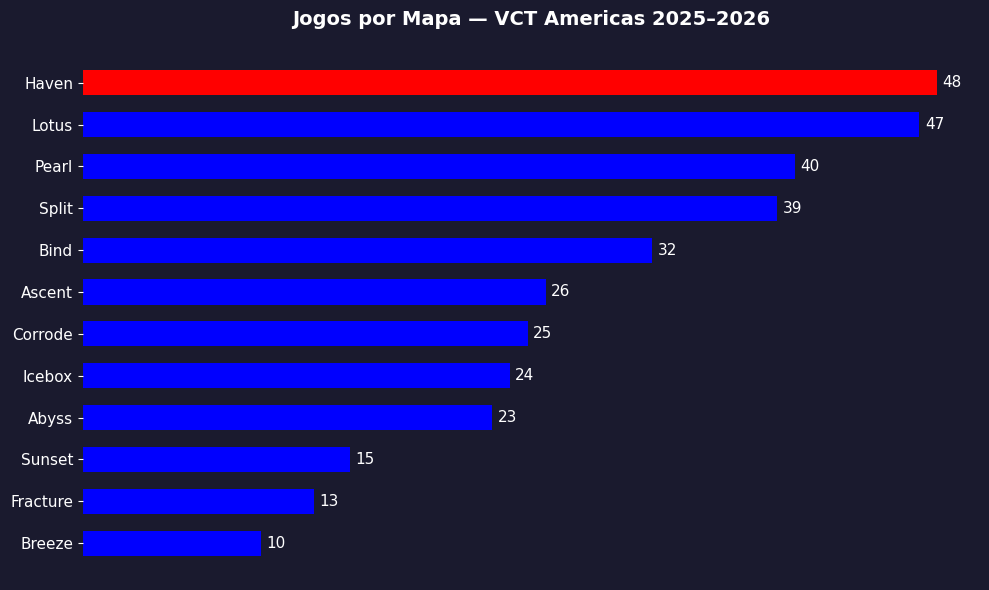

In [4]:
mapas = df_placar2["Mapa"].value_counts()

mapas = mapas.drop("AllMaps", errors="ignore")

mapas = mapas.sort_values()

fig, ax = plt.subplots(figsize=(10, 6))

cores = ['red' if v == mapas.max() else 'blue' for v in mapas.values]

bars = ax.barh(mapas.index, mapas.values, color=cores, edgecolor='none', height=0.6)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va='center',
        fontsize=11,
        color='white'
    )


ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

ax.tick_params(colors='white', labelsize=11)
ax.spines[:].set_visible(False)
ax.xaxis.set_visible(False)

ax.set_title(
    'Jogos por Mapa — VCT Americas 2025–2026',
    color='white',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.tight_layout()
plt.show()


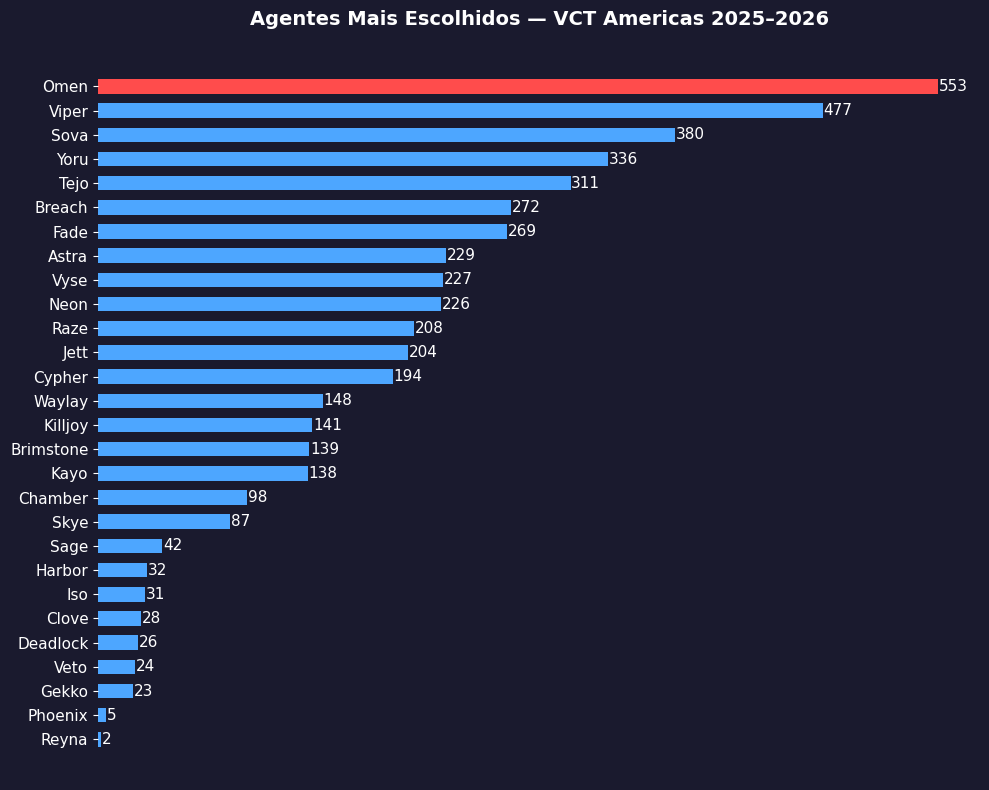

In [7]:
agentes = df_merged["Agente"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 8))

cores = ['#ff4c4c' if v == agentes.max() else '#4da6ff' for v in agentes.values]

bars = ax.barh(agentes.index, agentes.values, color=cores, edgecolor='none', height=0.6)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va='center',
        fontsize=11,
        color='white'
    )

ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

ax.tick_params(colors='white', labelsize=11)
ax.spines[:].set_visible(False)
ax.xaxis.set_visible(False)

ax.set_title(
    'Agentes Mais Escolhidos — VCT Americas 2025–2026',
    color='white',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.tight_layout()
plt.show()


/tmp/ipykernel_13599/1878259722.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdYlGn', n + 2)


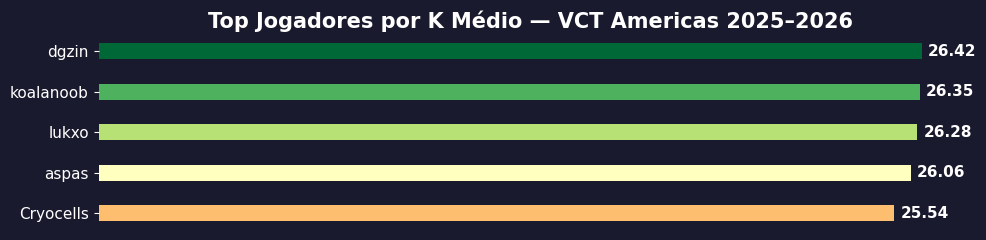

In [8]:
rating_por_jogador = (
    df_merged
    .groupby('Jogador')['K']
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

n = len(rating_por_jogador)

fig, ax = plt.subplots(figsize=(10, n * 0.5))

cmap = plt.cm.get_cmap('RdYlGn', n + 2)
cores = [cmap(i + 2) for i in range(n)]

bars = ax.barh(
    rating_por_jogador.index[::-1],
    rating_por_jogador.values[::-1],
    color=cores,
    edgecolor='none',
    height=0.4
)

for bar, val in zip(bars, rating_por_jogador.values[::-1]):
    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}',
        va='center',
        fontsize=11,
        fontweight='bold',
        color='white'
    )

ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

ax.tick_params(colors='white', labelsize=11)
ax.spines[:].set_visible(False)
ax.xaxis.set_visible(False)

ax.set_title(
    'Top Jogadores por K Médio — VCT Americas 2025–2026',
    color='white',
    fontsize=15,
    fontweight='bold',
    pad=5
)

plt.tight_layout()
plt.show()


In [10]:
df_allmap = df_placar2[
    (df_placar2['Mapa'] == 'AllMaps') &
    (df_placar2['Mapas_T1'].notna()) &
    (df_placar2['Mapas_T2'].notna())
].drop_duplicates(subset='URL', keep='last')

total_rounds = df_allmap['Score_T1'].sum() + df_allmap['Score_T2'].sum()
print(f"Total de rounds jogados: {int(total_rounds)}")
print()

score_t1 = df_allmap.groupby('Time1')['Score_T1'].sum()
score_t2 = df_allmap.groupby('Time2')['Score_T2'].sum()

score_total = (
    score_t1
    .add(score_t2, fill_value=0)
    .sort_values(ascending=False)
    .astype(int)
)

print(score_total)


Total de rounds jogados: 7196

Time1
G2 Esports               916
Sentinels                774
MIBR                     734
100 Thieves              701
NRG                      696
Cloud9                   671
Evil Geniuses            520
LEVIATÁN                 515
LOUD                     428
FURIA                    335
VISA KRÜ(KRÜ Esports)    324
2Game Esports            229
KRÜ Esports              204
ENVY                     149
dtype: int64


/tmp/ipykernel_13599/1893477881.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdYlGn', len(score_total) + 2)


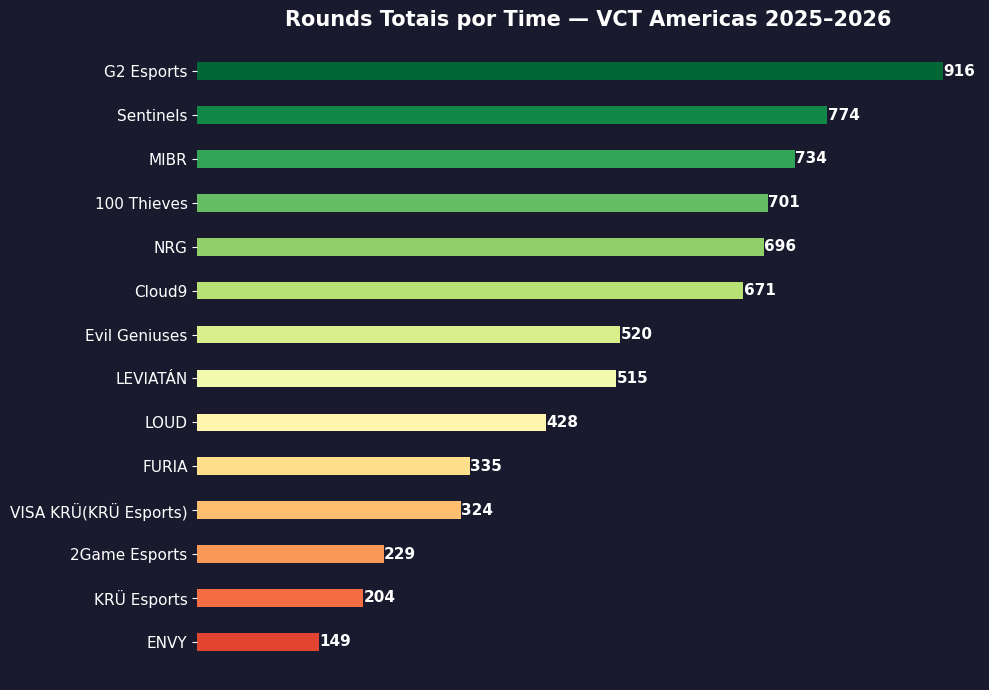

In [11]:
score_total = score_total.sort_values()

fig, ax = plt.subplots(figsize=(10, len(score_total) * 0.5))

cmap = plt.cm.get_cmap('RdYlGn', len(score_total) + 2)
cores = [cmap(i + 2) for i in range(len(score_total))]

bars = ax.barh(
    score_total.index,
    score_total.values,
    color=cores,
    edgecolor='none',
    height=0.4
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va='center',
        fontsize=11,
        fontweight='bold',
        color='white'
    )

ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

ax.tick_params(colors='white', labelsize=11)
ax.spines[:].set_visible(False)
ax.xaxis.set_visible(False)

ax.set_title(
    'Rounds Totais por Time — VCT Americas 2025–2026',
    color='white',
    fontsize=15,
    fontweight='bold',
    pad=5
)

plt.tight_layout()
plt.show()


/tmp/ipykernel_13599/3914516315.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm', len(top_agente) + 2)


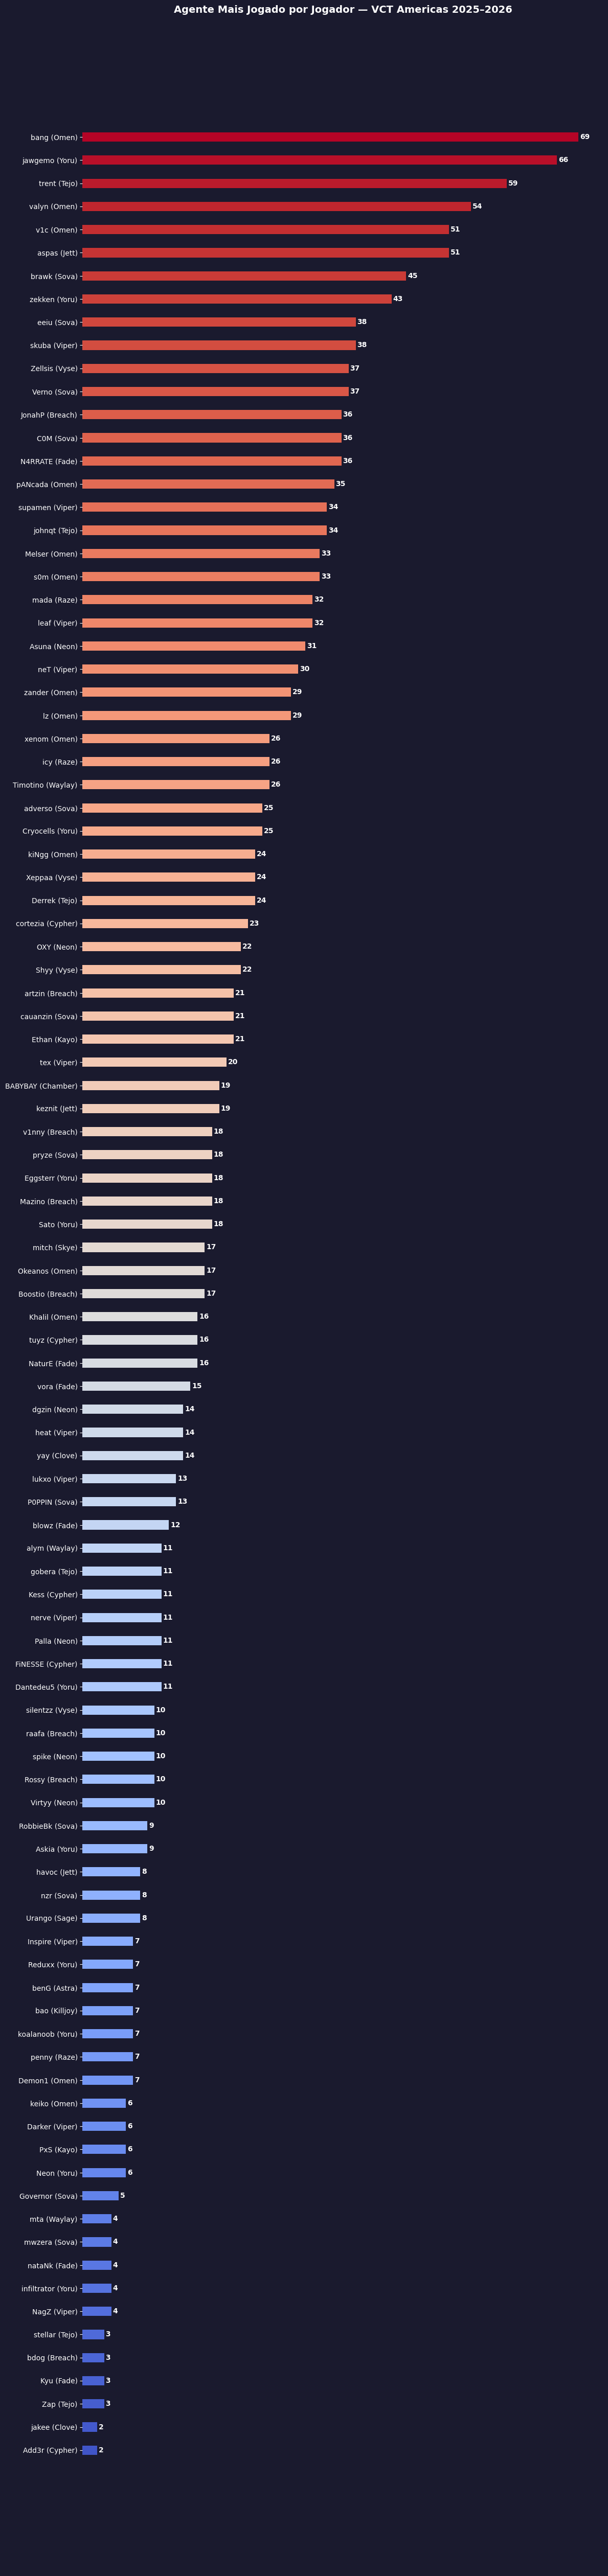

In [12]:
df_mapas = df_merged.copy()

agente_jogador = (
    df_mapas.groupby(['Jogador', 'Agente'])
    .size()
    .reset_index(name='Partidas')
    .sort_values('Partidas', ascending=False)
)

top_agente = (
    agente_jogador
    .groupby('Jogador')
    .first()
    .reset_index()
    .sort_values('Partidas')
)

fig, ax = plt.subplots(figsize=(12, len(top_agente) * 0.5))

cmap = plt.cm.get_cmap('coolwarm', len(top_agente) + 2)
cores = [cmap(i + 2) for i in range(len(top_agente))]

labels = [f"{row.Jogador} ({row.Agente})" for _, row in top_agente.iterrows()]

bars = ax.barh(
    labels,
    top_agente['Partidas'].values,
    color=cores,
    edgecolor='none',
    height=0.4
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va='center',
        fontsize=10,
        fontweight='bold',
        color='white'
    )

ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

ax.tick_params(colors='white', labelsize=10)
ax.spines[:].set_visible(False)
ax.xaxis.set_visible(False)

ax.set_title(
    'Agente Mais Jogado por Jogador — VCT Americas 2025–2026',
    color='white',
    fontsize=14,
    fontweight='bold',
    pad=5
)

plt.tight_layout()
plt.show()


/tmp/ipykernel_13599/3951895548.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdYlGn', len(stats_agente) + 2)


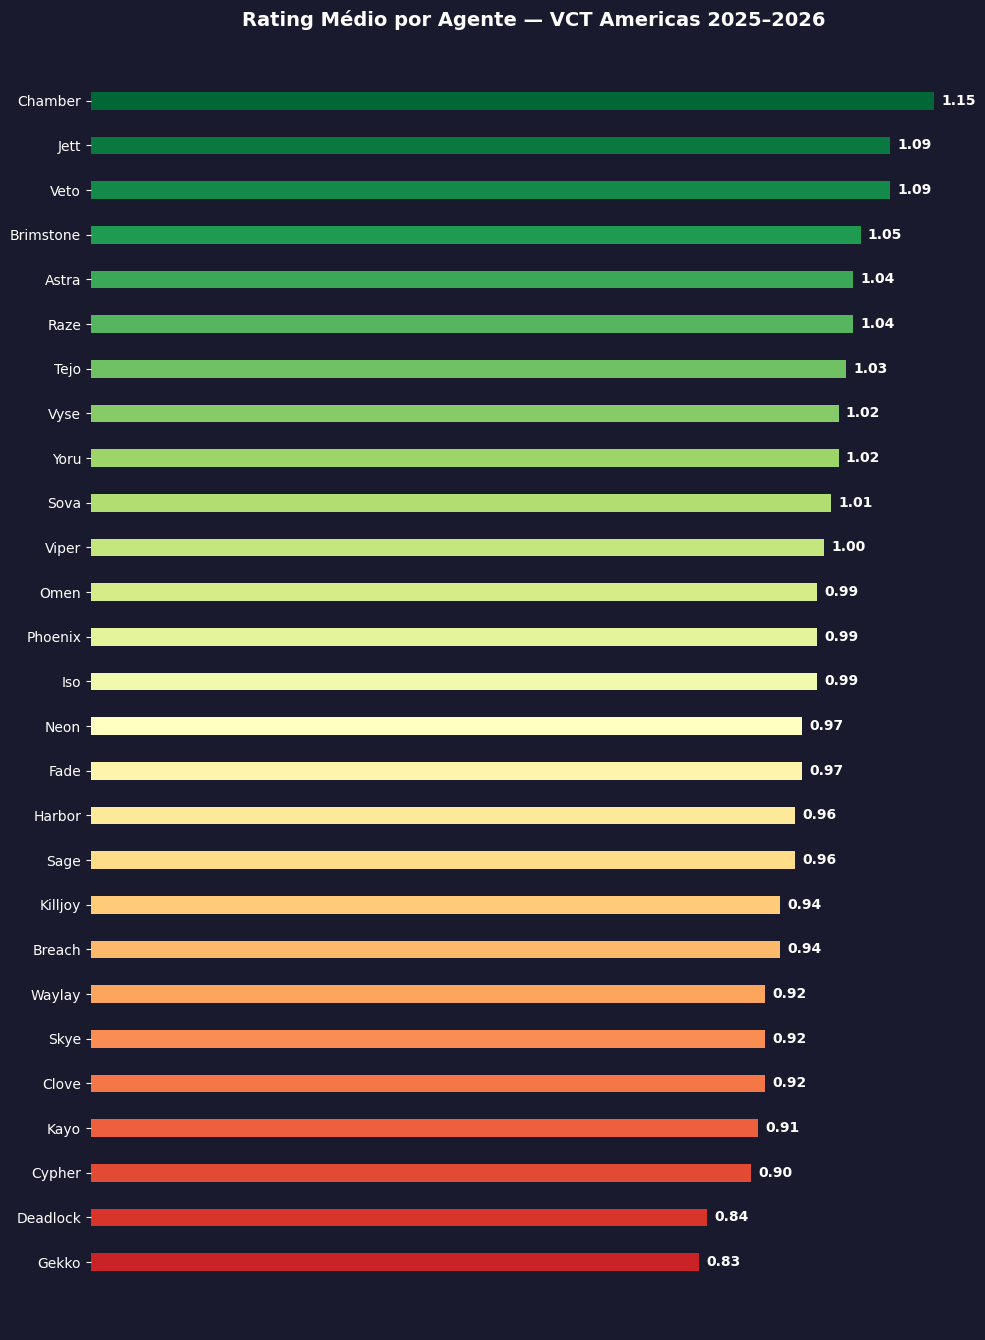

In [13]:
df_mapas = df_merged.copy()

stats_agente = (
    df_mapas.groupby('Agente')
    .agg(
        Partidas=('Agente', 'count'),
        Rating=('R', 'mean'),
        ACS=('ACS', 'mean'),
        KD=('K', 'sum'),
        Deaths=('D', 'sum'),
        KAST=('KAST', 'mean'),
        ADR=('ADR', 'mean'),
    )
    .assign(KD=lambda x: (x['KD'] / x['Deaths']).round(2))
    .query('Partidas >= 5')
    .sort_values('Rating')
    .round(2)
)

fig, ax = plt.subplots(figsize=(10, len(stats_agente) * 0.5))

cmap = plt.cm.get_cmap('RdYlGn', len(stats_agente) + 2)
cores = [cmap(i + 2) for i in range(len(stats_agente))]

bars = ax.barh(
    stats_agente.index,
    stats_agente['Rating'].values,
    color=cores,
    edgecolor='none',
    height=0.4
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va='center',
        fontsize=10,
        fontweight='bold',
        color='white'
    )

ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

ax.tick_params(colors='white', labelsize=10)
ax.spines[:].set_visible(False)
ax.xaxis.set_visible(False)

ax.set_title(
    'Rating Médio por Agente — VCT Americas 2025–2026',
    color='white',
    fontsize=14,
    fontweight='bold',
    pad=5
)

plt.tight_layout()
plt.show()


/tmp/ipykernel_13599/1358663649.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = plt.cm.get_cmap('coolwarm', len(melhor_por_mapa) + 2)


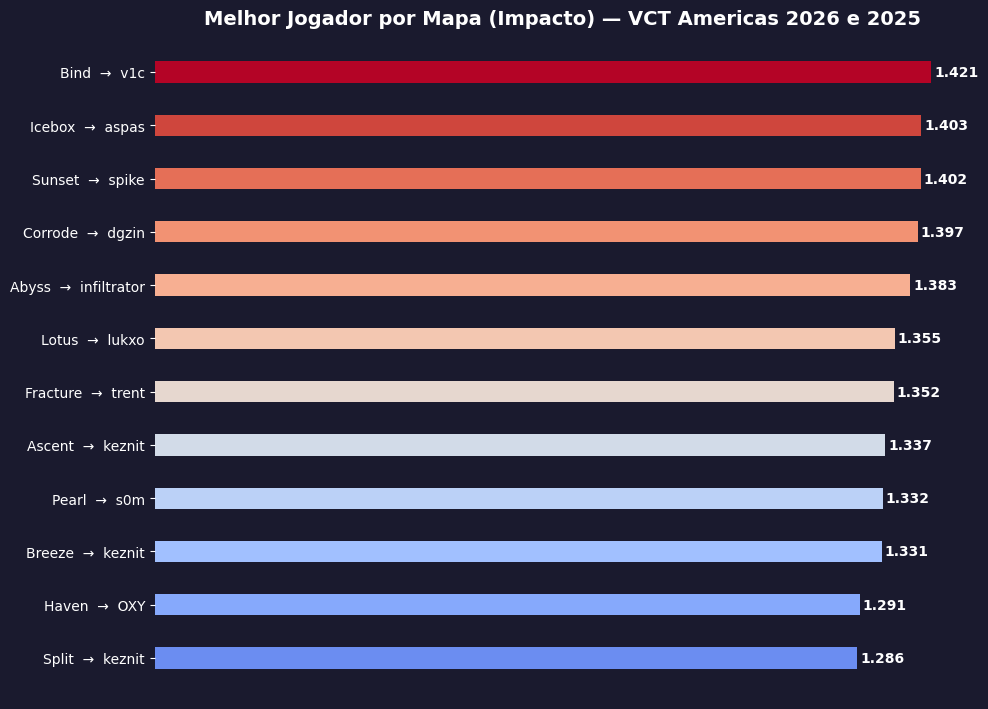

In [17]:
melhor_por_mapa = (df_jog_map.groupby(['Mapa', 'Jogador'])
                   .agg(Impacto=('Impacto', 'mean'), Partidas=('Jogos', 'sum'))
                   .query('Partidas >= 2')
                   .reset_index()
                   .sort_values('Impacto', ascending=False)
                   .groupby('Mapa')
                   .first()
                   .reset_index()
                   .sort_values('Impacto', ascending=False))

fig, ax = plt.subplots(figsize=(10, len(melhor_por_mapa) * 0.6))
cmap2 = plt.cm.get_cmap('coolwarm', len(melhor_por_mapa) + 2)
cores2 = [cmap2(i + 2) for i in range(len(melhor_por_mapa))]
labels = [f"{row.Mapa}  →  {row.Jogador}" for _, row in melhor_por_mapa[::-1].iterrows()]
bars = ax.barh(labels, melhor_por_mapa['Impacto'].values[::-1],
               color=cores2, edgecolor='none', height=0.4)
for bar, val in zip(bars, melhor_por_mapa['Impacto'].values[::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=10, fontweight='bold', color='white')
ax.set_facecolor('#1a1a2e'); fig.patch.set_facecolor('#1a1a2e')
ax.tick_params(colors='white', labelsize=10); ax.spines[:].set_visible(False); ax.xaxis.set_visible(False)
ax.set_title('Melhor Jogador por Mapa (Impacto) — VCT Americas 2026 e 2025',
             color='white', fontsize=14, fontweight='bold', pad=5)
plt.tight_layout()
plt.show()

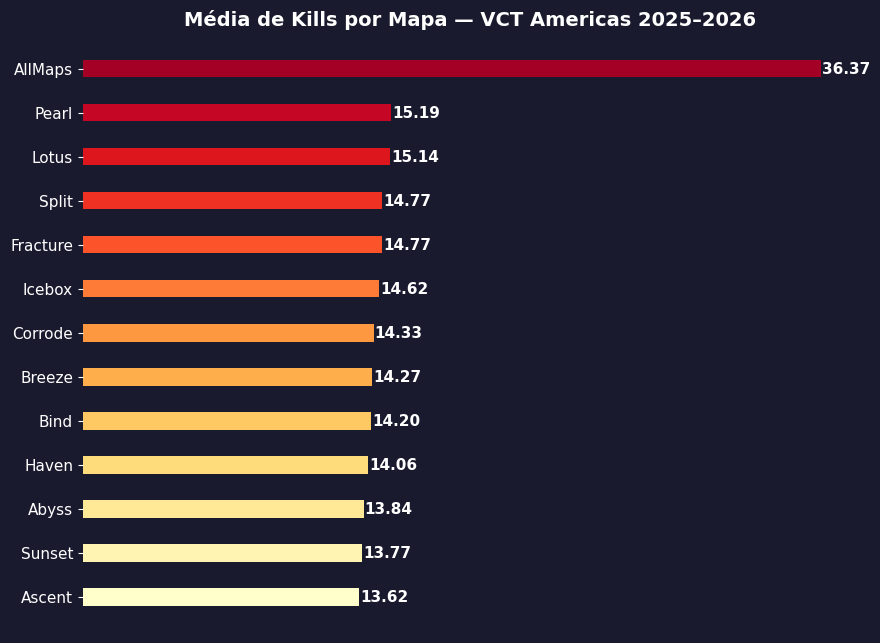

In [18]:
kills_por_mapa = (
    df_merged.groupby('Mapa')['K']
    .mean()
    .sort_values()
    .round(2)
)

fig, ax = plt.subplots(figsize=(10, max(len(kills_por_mapa) * 0.6, 4)))

cmap3 = plt.colormaps.get_cmap('YlOrRd')
cores3 = [cmap3(i / len(kills_por_mapa)) for i in range(len(kills_por_mapa))]

bars = ax.barh(
    kills_por_mapa.index,
    kills_por_mapa.values,
    color=cores3,
    edgecolor='none',
    height=0.4
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va='center',
        fontsize=11,
        fontweight='bold',
        color='white'
    )

ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

ax.tick_params(colors='white', labelsize=11)
ax.spines[:].set_visible(False)
ax.xaxis.set_visible(False)

ax.set_title(
    'Média de Kills por Mapa — VCT Americas 2025–2026',
    color='white',
    fontsize=14,
    fontweight='bold',
    pad=5
)

plt.show()


/tmp/ipykernel_13599/3229346560.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('plasma', len(df_impacto))


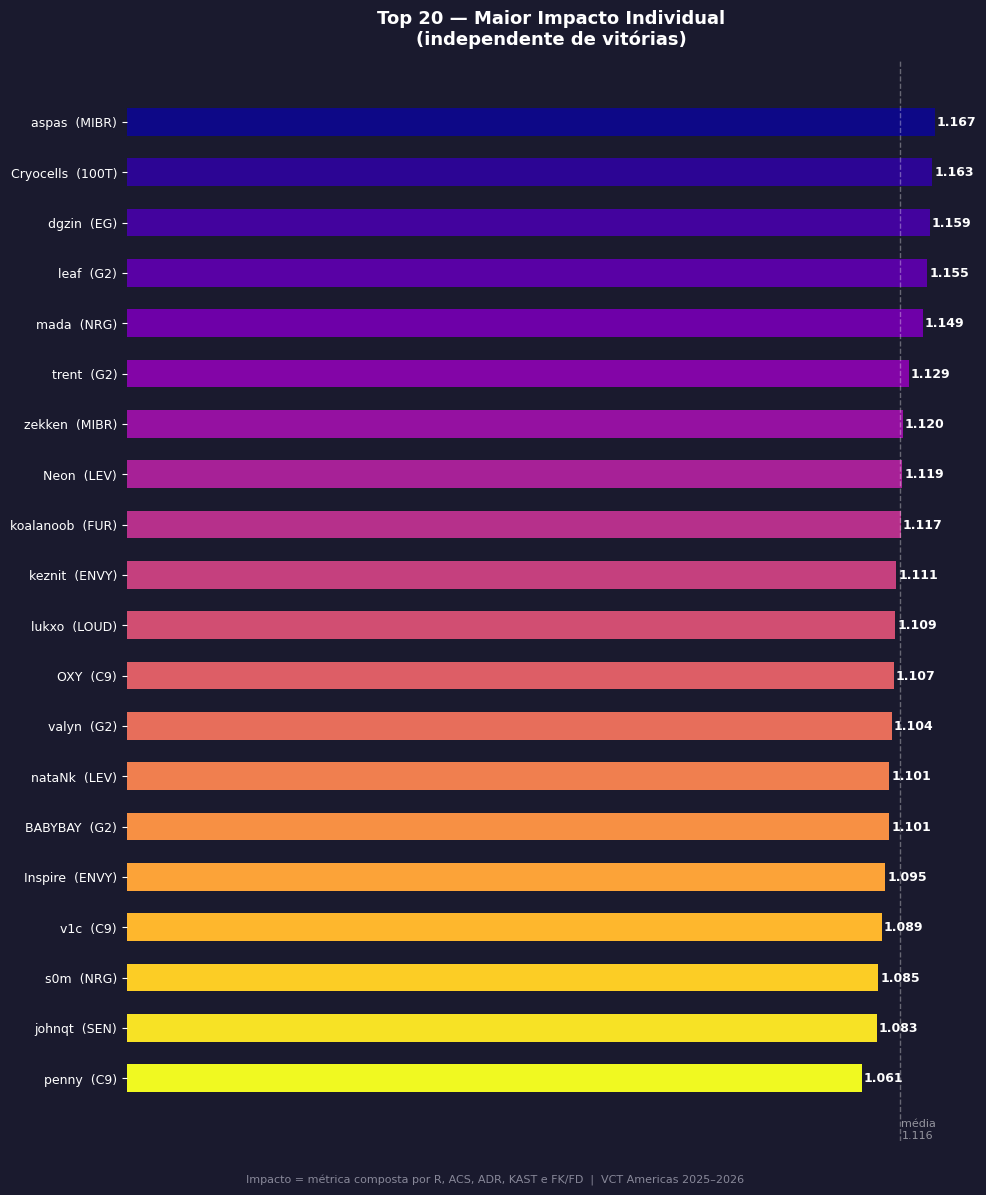

In [23]:
df_impacto = (df_jog_map.groupby(['Jogador', 'Time'])
              .agg(
                  Impacto=('Impacto', 'mean'),
                  Jogos=('Jogos', 'sum'),
              )
              .query('Jogos >= 4')
              .reset_index()
              .sort_values('Impacto', ascending=False)
              .head(20))

fig, ax = plt.subplots(figsize=(10, len(df_impacto) * 0.6))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

cmap = plt.cm.get_cmap('plasma', len(df_impacto))
cores = [cmap(i) for i in range(len(df_impacto))]

labels = [f"{row.Jogador}  ({row.Time})" for _, row in df_impacto[::-1].iterrows()]
bars = ax.barh(labels, df_impacto['Impacto'].values[::-1],
               color=cores[::-1], edgecolor='none', height=0.55)

for bar, val in zip(bars, df_impacto['Impacto'].values[::-1]):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9, fontweight='bold', color='white')

media = df_impacto['Impacto'].mean()
ax.axvline(media, color='#ffffff55', linestyle='--', linewidth=1)
ax.text(media + 0.002, -0.8, f'média\n{media:.3f}',
        color='#ffffff88', fontsize=8, va='top')

ax.tick_params(colors='white', labelsize=9)
ax.spines[:].set_visible(False)
ax.xaxis.set_visible(False)
ax.set_title('Top 20 — Maior Impacto Individual\n(independente de vitórias)',
             color='white', fontsize=13, fontweight='bold', pad=10)

fig.text(0.5, 0.01,
         'Impacto = métrica composta por R, ACS, ADR, KAST e FK/FD  |  VCT Americas 2025–2026',
         ha='center', color='#888899', fontsize=8)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

/tmp/ipykernel_13599/4265556079.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('autumn', len(df_clutch))


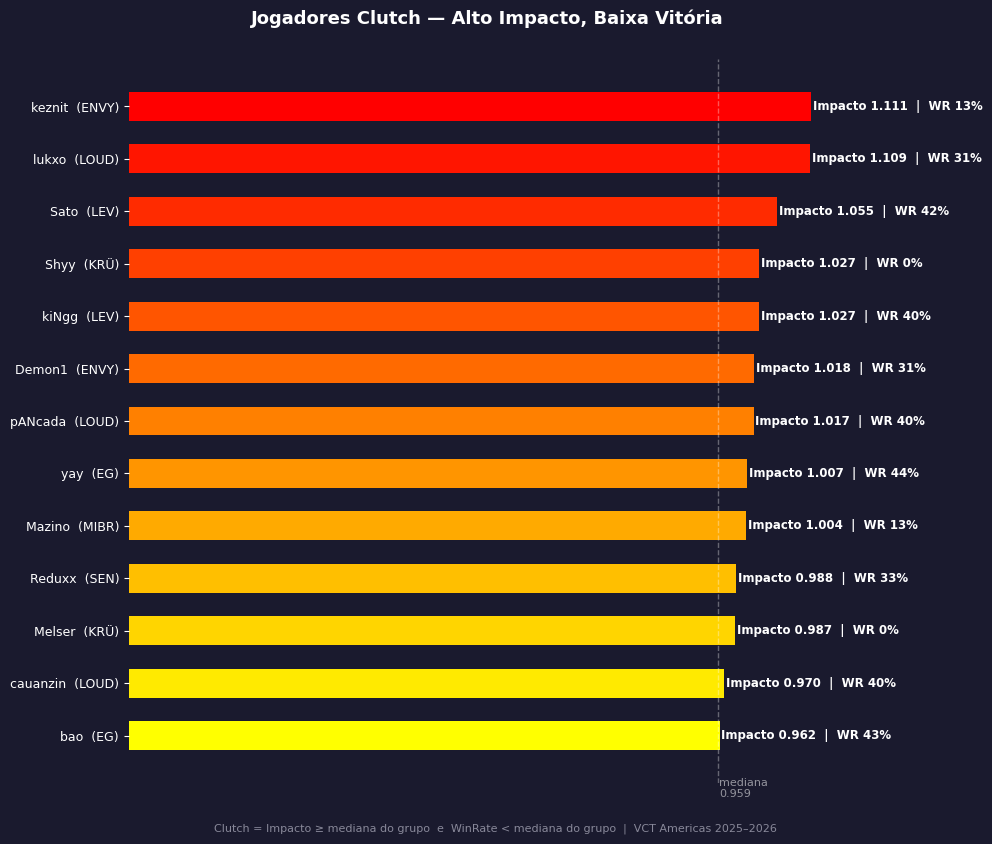

In [25]:
df_impacto = (df_jog_map.groupby(['Jogador', 'Time'])
              .agg(
                  Impacto=('Impacto', 'mean'),
                  Jogos=('Jogos', 'sum'),
                  WinRate=('WinRate', 'mean'),
              )
              .query('Jogos >= 4')
              .reset_index())

# Filtro clutch: impacto acima da mediana, winrate abaixo da mediana
med_imp = df_impacto['Impacto'].median()
med_wr  = df_impacto['WinRate'].median()

df_clutch = (df_impacto
             .query('Impacto >= @med_imp and WinRate < @med_wr')
             .sort_values('Impacto', ascending=False)
             .head(15))

fig, ax = plt.subplots(figsize=(10, len(df_clutch) * 0.65))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

cmap = plt.cm.get_cmap('autumn', len(df_clutch))
cores = [cmap(i) for i in range(len(df_clutch))]

labels = [f"{row.Jogador}  ({row.Time})" for _, row in df_clutch[::-1].iterrows()]
bars = ax.barh(labels, df_clutch['Impacto'].values[::-1],
               color=cores[::-1], edgecolor='none', height=0.55)

# Valor de Impacto + WinRate no fim de cada barra
for bar, (_, row) in zip(bars, df_clutch[::-1].iterrows()):
    ax.text(bar.get_width() + 0.003,
            bar.get_y() + bar.get_height() / 2,
            f'Impacto {row.Impacto:.3f}  |  WR {row.WinRate:.0%}',
            va='center', fontsize=8.5, fontweight='bold', color='white')

# Linha de referência — mediana de impacto
ax.axvline(med_imp, color='#ffffff55', linestyle='--', linewidth=1)
ax.text(med_imp + 0.002, -0.8, f'mediana\n{med_imp:.3f}',
        color='#ffffff88', fontsize=8, va='top')

ax.tick_params(colors='white', labelsize=9)
ax.spines[:].set_visible(False)
ax.xaxis.set_visible(False)
ax.set_title('Jogadores Clutch — Alto Impacto, Baixa Vitória\n',
             color='white', fontsize=13, fontweight='bold', pad=10)

fig.text(0.5, 0.01,
         'Clutch = Impacto ≥ mediana do grupo  e  WinRate < mediana do grupo  |  VCT Americas 2025–2026',
         ha='center', color='#888899', fontsize=8)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

/tmp/ipykernel_13599/2507663945.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('cool', len(melhor_time_mapa))


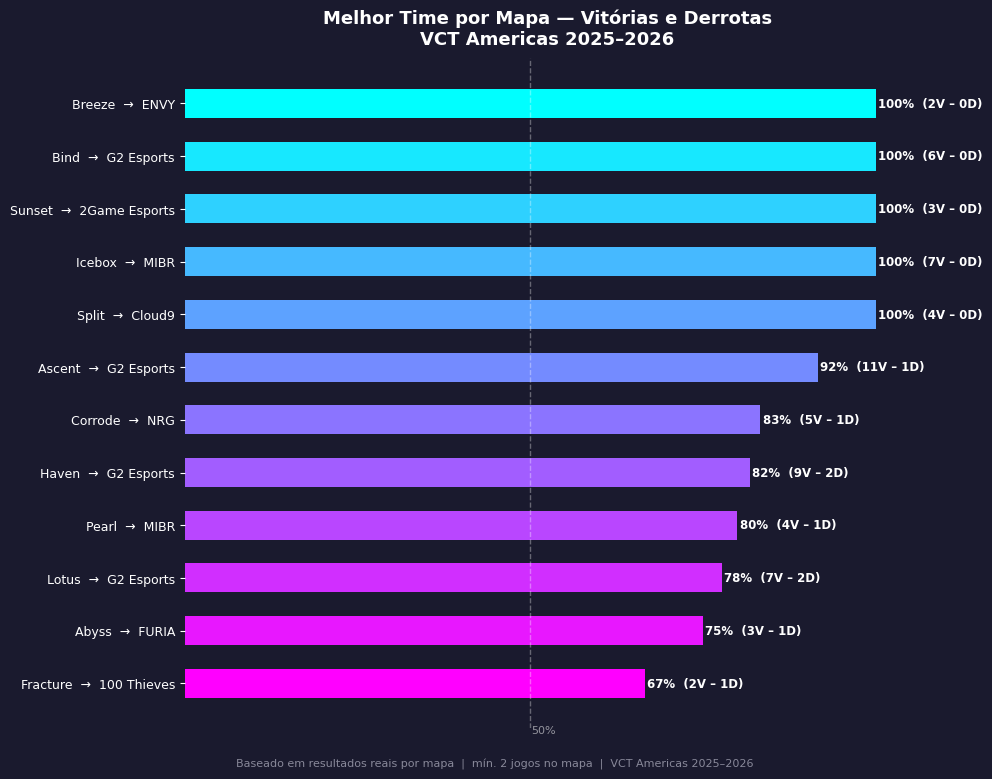

In [27]:
df_mapas = df_placar2[df_placar2['Mapa'] != 'AllMaps'].copy()

# Montar registros de vitória/derrota por time e mapa
registros = []
for _, row in df_mapas.iterrows():
    registros.append({'Time': row['Time1'], 'Mapa': row['Mapa'], 'Vitoria': 1 if row['Vencedor'] == row['Time1'] else 0})
    registros.append({'Time': row['Time2'], 'Mapa': row['Mapa'], 'Vitoria': 1 if row['Vencedor'] == row['Time2'] else 0})

df_vd = pd.DataFrame(registros)

# Agregar por Time e Mapa
df_time_mapa = (df_vd.groupby(['Time', 'Mapa'])
                .agg(Jogos=('Vitoria', 'count'), Vitorias=('Vitoria', 'sum'))
                .reset_index())
df_time_mapa['Derrotas'] = df_time_mapa['Jogos'] - df_time_mapa['Vitorias']
df_time_mapa['WinRate'] = df_time_mapa['Vitorias'] / df_time_mapa['Jogos']

# Melhor time por mapa (maior WinRate, mínimo 2 jogos)
melhor_time_mapa = (df_time_mapa
                    .query('Jogos >= 2')
                    .sort_values(['WinRate', 'Vitorias'], ascending=False)
                    .groupby('Mapa')
                    .first()
                    .reset_index()
                    .sort_values('WinRate', ascending=False))

fig, ax = plt.subplots(figsize=(10, len(melhor_time_mapa) * 0.65))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

cmap = plt.cm.get_cmap('cool', len(melhor_time_mapa))
cores = [cmap(i) for i in range(len(melhor_time_mapa))]

labels = [f"{row.Mapa}  →  {row.Time}" for _, row in melhor_time_mapa[::-1].iterrows()]
bars = ax.barh(labels, melhor_time_mapa['WinRate'].values[::-1],
               color=cores[::-1], edgecolor='none', height=0.55)

for bar, (_, row) in zip(bars, melhor_time_mapa[::-1].iterrows()):
    ax.text(bar.get_width() + 0.003,
            bar.get_y() + bar.get_height() / 2,
            f'{row.WinRate:.0%}  ({int(row.Vitorias)}V – {int(row.Derrotas)}D)',
            va='center', fontsize=8.5, fontweight='bold', color='white')

# Linha de 50%
ax.axvline(0.5, color='#ffffff55', linestyle='--', linewidth=1)
ax.text(0.502, -0.8, '50%', color='#ffffff88', fontsize=8, va='top')

ax.tick_params(colors='white', labelsize=9)
ax.spines[:].set_visible(False)
ax.xaxis.set_visible(False)
ax.set_title('Melhor Time por Mapa — Vitórias e Derrotas\nVCT Americas 2025–2026',
             color='white', fontsize=13, fontweight='bold', pad=10)

fig.text(0.5, 0.01,
         'Baseado em resultados reais por mapa  |  mín. 2 jogos no mapa  |  VCT Americas 2025–2026',
         ha='center', color='#888899', fontsize=8)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

In [6]:
df = df_placar2[df_placar2["Mapa"] != "AllMaps"].copy()

times = sorted(set(df["Time1"]).union(set(df["Time2"])))

wins  = pd.DataFrame(0, index=times, columns=times)
jogos = pd.DataFrame(0, index=times, columns=times)

for _, row in df.iterrows():
    t1, t2, v = row["Time1"], row["Time2"], row["Vencedor"]
    if t1 == t2 or pd.isna(v):
        continue
    jogos.loc[t1, t2] += 1
    jogos.loc[t2, t1] += 1
    if v == t1:
        wins.loc[t1, t2] += 1
    elif v == t2:
        wins.loc[t2, t1] += 1

# Lista de resultados
resultado = []

for t1 in times:
    for t2 in times:
        if t1 >= t2:
            continue
        n = jogos.loc[t1, t2]
        if n == 0:
            continue
        w1 = int(wins.loc[t1, t2])
        w2 = int(wins.loc[t2, t1])
        resultado.append(f"{t1} ganhou {w1}x e perdeu {w2}x contra {t2} — {w1/n*100:.0f}% de winrate ({n} mapas)")
        resultado.append(f"{t2} ganhou {w2}x e perdeu {w1}x contra {t1} — {w2/n*100:.0f}% de winrate ({n} mapas)")

for linha in sorted(resultado):
    print(linha)

100 Thieves ganhou 2x e perdeu 0x contra 2Game Esports — 100% de winrate (2 mapas)
100 Thieves ganhou 2x e perdeu 2x contra VISA KRÜ(KRÜ Esports) — 50% de winrate (4 mapas)
100 Thieves ganhou 2x e perdeu 3x contra Cloud9 — 40% de winrate (5 mapas)
100 Thieves ganhou 2x e perdeu 4x contra MIBR — 33% de winrate (6 mapas)
100 Thieves ganhou 2x e perdeu 6x contra G2 Esports — 25% de winrate (8 mapas)
100 Thieves ganhou 3x e perdeu 3x contra LEVIATÁN — 50% de winrate (6 mapas)
100 Thieves ganhou 4x e perdeu 4x contra Sentinels — 50% de winrate (8 mapas)
100 Thieves ganhou 5x e perdeu 6x contra NRG — 45% de winrate (11 mapas)
100 Thieves ganhou 6x e perdeu 0x contra Evil Geniuses — 100% de winrate (6 mapas)
100 Thieves ganhou 6x e perdeu 3x contra LOUD — 67% de winrate (9 mapas)
2Game Esports ganhou 0x e perdeu 2x contra 100 Thieves — 0% de winrate (2 mapas)
2Game Esports ganhou 0x e perdeu 2x contra Cloud9 — 0% de winrate (2 mapas)
2Game Esports ganhou 0x e perdeu 2x contra G2 Esports — 0% 

In [9]:
rows = []

for t1 in times:
    for t2 in times:
        if t1 >= t2:
            continue
        n = jogos.loc[t1, t2]
        if n == 0:
            continue
        w1 = int(wins.loc[t1, t2])
        w2 = int(wins.loc[t2, t1])
        rows.append({"Time": t1, "Adversario": t2, "Vitorias": w1, "Derrotas": w2, "Mapas": int(n), "WinRate": round(w1/n*100, 1)})
        rows.append({"Time": t2, "Adversario": t1, "Vitorias": w2, "Derrotas": w1, "Mapas": int(n), "WinRate": round(w2/n*100, 1)})

df_matchups = pd.DataFrame(rows).sort_values(["Time", "Adversario"]).reset_index(drop=True)
df_matchups.to_csv("matchups_score.csv", index=False)
df_matchups

,Time,Adversario,Vitorias,Derrotas,Mapas,WinRate
0,100 Thieves,2Game Esports,2,0,2,100.0
1,100 Thieves,Cloud9,2,3,5,40.0
2,100 Thieves,Evil Geniuses,6,0,6,100.0
3,100 Thieves,G2 Esports,2,6,8,25.0
4,100 Thieves,LEVIATÁN,3,3,6,50.0
...,...,...,...,...,...,...
125,VISA KRÜ(KRÜ Esports),LEVIATÁN,2,4,6,33.3
126,VISA KRÜ(KRÜ Esports),LOUD,4,2,6,66.7
127,VISA KRÜ(KRÜ Esports),MIBR,2,3,5,40.0
128,VISA KRÜ(KRÜ Esports),NRG,1,2,3,33.3


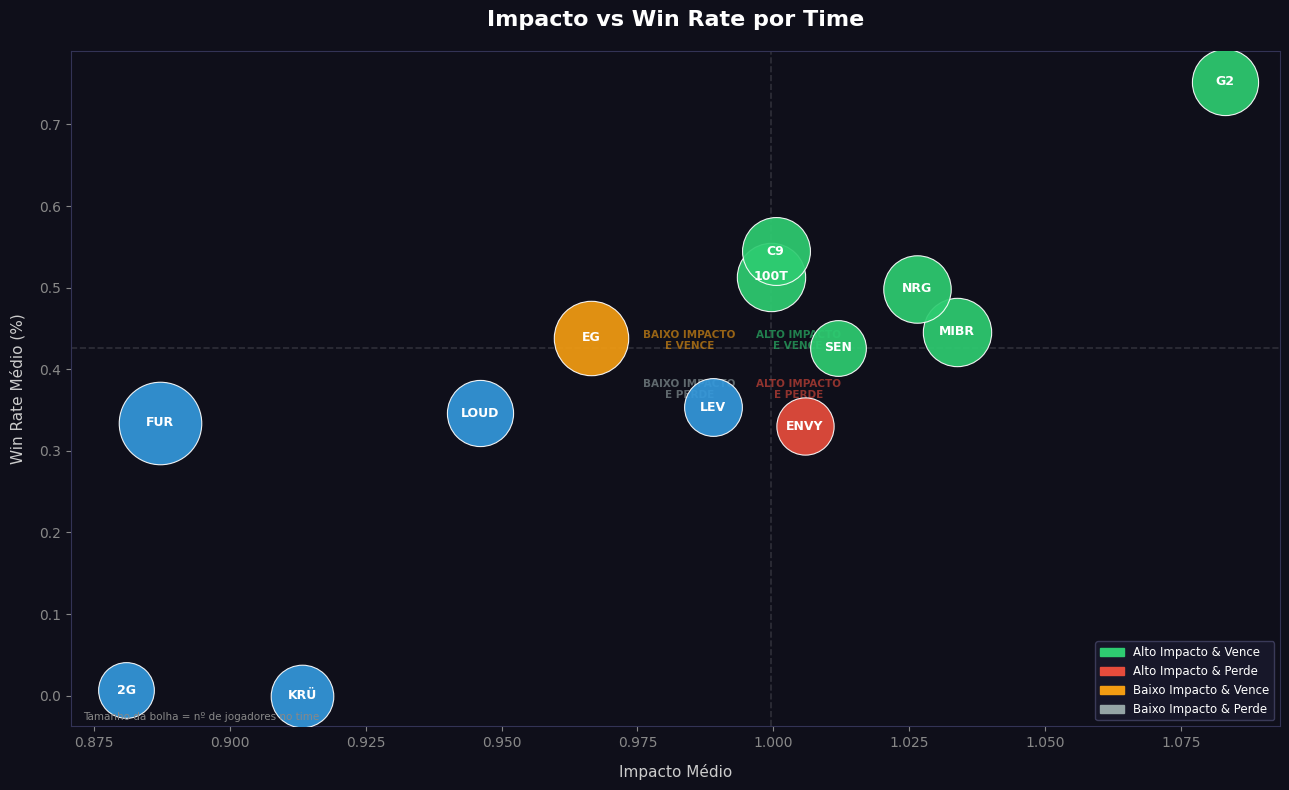

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


df = df_jog_map.copy()

df_time = (
    df.groupby("Time")
    .agg(
        Impacto_medio=("Impacto", "mean"),
        WinRate_medio=("WinRate", "mean"),
        Jogadores=("Jogador", "count"),
    )
    .reset_index()
)

# ─── Quadrantes (baseados na mediana) ─────────────────────────────────────────
med_impacto = df_time["Impacto_medio"].median()
med_winrate = df_time["WinRate_medio"].median()

def quadrante(row):
    alto_imp = row["Impacto_medio"] >= med_impacto
    alta_wr  = row["WinRate_medio"]  >= med_winrate
    if alto_imp and alta_wr:
        return "Alto Impacto\n& Vence", "#2ecc71"        # verde
    elif alto_imp and not alta_wr:
        return "Alto Impacto\n& Perde", "#e74c3c"        # vermelho
    elif not alto_imp and alta_wr:
        return "Baixo Impacto\n& Vence", "#f39c12"       # laranja
    else:
        return "Baixo Impacto\n& Perde", "#3498db"       # cinza

df_time[["Quadrante", "Cor"]] = df_time.apply(
    quadrante, axis=1, result_type="expand"
)

# ─── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor("#0f0f1a")
ax.set_facecolor("#0f0f1a")

# Linhas dos quadrantes
ax.axvline(med_impacto, color="#ffffff22", linewidth=1.2, linestyle="--")
ax.axhline(med_winrate,  color="#ffffff22", linewidth=1.2, linestyle="--")

# Rótulos de fundo dos quadrantes
quadrante_labels = [
    (med_impacto * 1.005, med_winrate * 1.02,  "ALTO IMPACTO\nE VENCE",  "#2ecc7122"),
    (med_impacto * 0.985, med_winrate * 1.02,  "BAIXO IMPACTO\nE VENCE", "#f39c1222"),
    (med_impacto * 1.005, med_winrate * 0.88,  "ALTO IMPACTO\nE PERDE",  "#e74c3c22"),
    (med_impacto * 0.985, med_winrate * 0.88,  "BAIXO IMPACTO\nE PERDE", "#95a5a622"),
]
for x, y, txt, cor in quadrante_labels:
    ax.text(x, y, txt, fontsize=7.5, color=cor[:-2] + "99",
            ha="center", va="center", fontweight="bold", alpha=0.6)

# Scatter por time
for _, row in df_time.iterrows():
    tamanho = 200 + row["Jogadores"] * 30   # bolha proporcional ao nº de jogadores
    ax.scatter(
        row["Impacto_medio"], row["WinRate_medio"],
        s=tamanho, color=row["Cor"], edgecolors="white",
        linewidths=0.8, alpha=0.92, zorder=3
    )
    ax.annotate(
        row["Time"],
        xy=(row["Impacto_medio"], row["WinRate_medio"]),
        xytext=(0, 0), textcoords="offset points",
        ha="center", va="center",
        fontsize=9, color="white", fontweight="bold",   
        zorder=4
    )

# ─── Estética dos eixos ───────────────────────────────────────────────────────
ax.set_xlabel("Impacto Médio", fontsize=11, color="#cccccc", labelpad=10)
ax.set_ylabel("Win Rate Médio (%)", fontsize=11, color="#cccccc", labelpad=10)
ax.set_title(
    "Impacto vs Win Rate por Time",
    fontsize=16, color="white", fontweight="bold", pad=18
)
ax.tick_params(colors="#888888")
for spine in ax.spines.values():
    spine.set_edgecolor("#333355")

# Legenda
patches = [
    mpatches.Patch(color="#2ecc71", label="Alto Impacto & Vence"),
    mpatches.Patch(color="#e74c3c", label="Alto Impacto & Perde"),
    mpatches.Patch(color="#f39c12", label="Baixo Impacto & Vence"),
    mpatches.Patch(color="#95a5a6", label="Baixo Impacto & Perde"),
]
ax.legend(
    handles=patches, loc="lower right", fontsize=8.5,
    facecolor="#1a1a2e", edgecolor="#444466", labelcolor="white"
)

ax.text(
    0.01, 0.01,
    "Tamanho da bolha = nº de jogadores no time",
    transform=ax.transAxes, fontsize=7.5, color="#888888"
)

plt.tight_layout()
plt.savefig("impacto_vs_winrate_por_time.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_15397/940776267.py:126: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


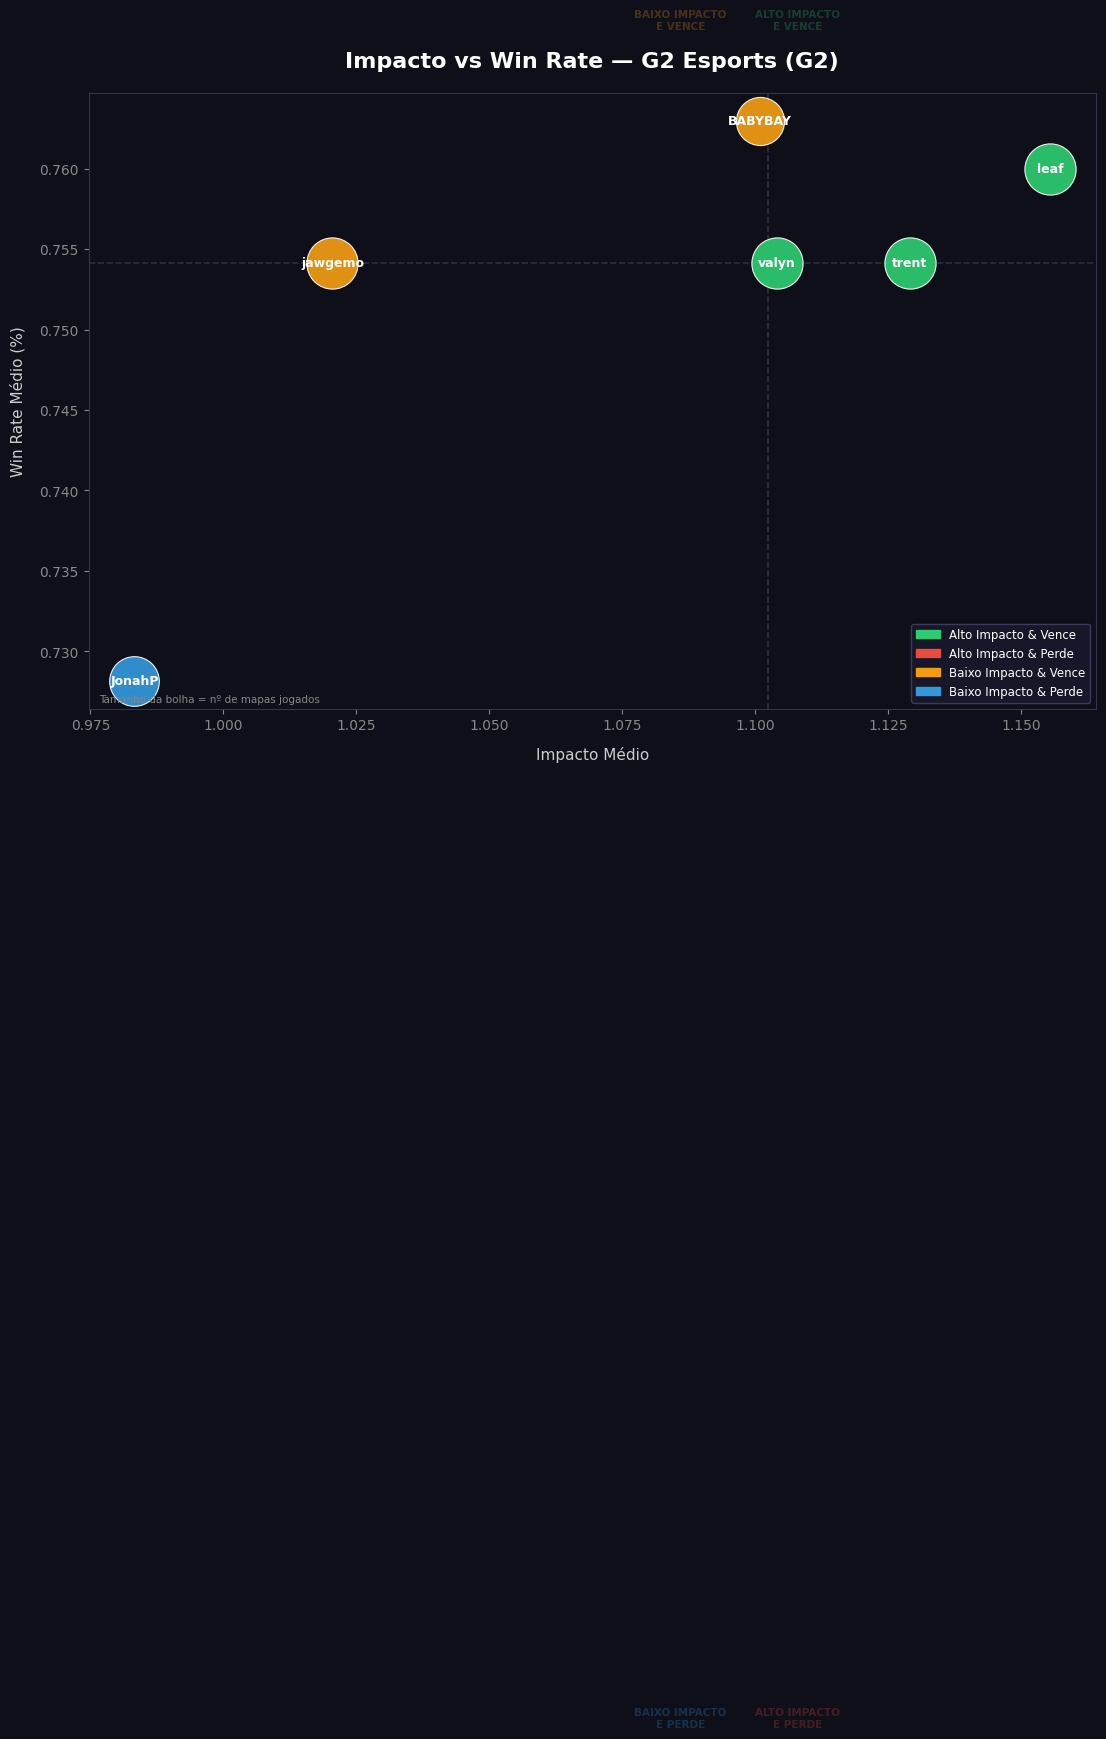

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

tag = {
    'SEN':  'Sentinels',
    'NRG':  'NRG',
    'C9':   'Cloud9',
    'FUR':  'FURIA',
    'LEV':  'LEVIATÁN',
    'EG':   'Evil Geniuses',
    '100T': '100 Thieves',
    'KRÜ':  'KRÜ Esports',   
    'G2':   'G2 Esports',
    'ENVY': 'ENVY',
    'MIBR': 'MIBR',
    'LOUD': 'LOUD',
    '2G':   '2G',            
}

TIME_SELECIONADO = "G2"  

TIME_NOME = tag.get(TIME_SELECIONADO.upper(), TIME_SELECIONADO)  

df_filtrado = df_jog_map[df_jog_map["Time"] == TIME_SELECIONADO].copy()

if df_filtrado.empty:
    raise ValueError(
        f"Time '{TIME_SELECIONADO}' não encontrado.\n"
        f"Tags disponíveis: {sorted(df_jog_map['Time'].unique().tolist())}"
    )

# ─── Agrega por jogador ───────────────────────────────────────────────────────
df_jog = (
    df_filtrado.groupby("Jogador")
    .agg(
        Impacto_medio=("Impacto", "mean"),
        WinRate_medio=("WinRate", "mean"),
        Mapas=("Mapa", "count"),
    )
    .reset_index()
)

# ─── Quadrantes ───────────────────────────────────────────────────────────────
med_impacto = df_jog["Impacto_medio"].median()
med_winrate  = df_jog["WinRate_medio"].median()

def quadrante(row):
    alto_imp = row["Impacto_medio"] >= med_impacto
    alta_wr  = row["WinRate_medio"]  >= med_winrate
    if alto_imp and alta_wr:
        return "Alto Impacto & Vence",  "#2ecc71"
    elif alto_imp and not alta_wr:
        return "Alto Impacto & Perde",  "#e74c3c"
    elif not alto_imp and alta_wr:
        return "Baixo Impacto & Vence", "#f39c12"
    else:
        return "Baixo Impacto & Perde", "#3498db"

df_jog[["Quadrante", "Cor"]] = df_jog.apply(
    quadrante, axis=1, result_type="expand"
)

# ─── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor("#0f0f1a")
ax.set_facecolor("#0f0f1a")

ax.axvline(med_impacto, color="#ffffff22", linewidth=1.2, linestyle="--")
ax.axhline(med_winrate,  color="#ffffff22", linewidth=1.2, linestyle="--")

quadrante_labels = [
    (med_impacto * 1.005, med_winrate * 1.02,  "ALTO IMPACTO\nE VENCE",  "#2ecc71"),
    (med_impacto * 0.985, med_winrate * 1.02,  "BAIXO IMPACTO\nE VENCE", "#f39c12"),
    (med_impacto * 1.005, med_winrate * 0.88,  "ALTO IMPACTO\nE PERDE",  "#e74c3c"),
    (med_impacto * 0.985, med_winrate * 0.88,  "BAIXO IMPACTO\nE PERDE", "#3498db"),
]
for x, y, txt, cor in quadrante_labels:
    ax.text(x, y, txt, fontsize=7.5, color=cor,
            ha="center", va="center", fontweight="bold", alpha=0.25)

for _, row in df_jog.iterrows():
    tamanho = 400 + row["Mapas"] * 80
    ax.scatter(
        row["Impacto_medio"], row["WinRate_medio"],
        s=tamanho, color=row["Cor"], edgecolors="white",
        linewidths=0.8, alpha=0.92, zorder=3
    )
    ax.annotate(
        row["Jogador"],
        xy=(row["Impacto_medio"], row["WinRate_medio"]),
        xytext=(0, 0), textcoords="offset points",
        ha="center", va="center",
        fontsize=9, color="white", fontweight="bold",
        zorder=4
    )

ax.set_xlabel("Impacto Médio", fontsize=11, color="#cccccc", labelpad=10)
ax.set_ylabel("Win Rate Médio (%)", fontsize=11, color="#cccccc", labelpad=10)
ax.set_title(
    f"Impacto vs Win Rate — {TIME_NOME} ({TIME_SELECIONADO})",
    fontsize=16, color="white", fontweight="bold", pad=18
)
ax.tick_params(colors="#888888")
for spine in ax.spines.values():
    spine.set_edgecolor("#333355")

patches = [
    mpatches.Patch(color="#2ecc71", label="Alto Impacto & Vence"),
    mpatches.Patch(color="#e74c3c", label="Alto Impacto & Perde"),
    mpatches.Patch(color="#f39c12", label="Baixo Impacto & Vence"),
    mpatches.Patch(color="#3498db", label="Baixo Impacto & Perde"),
]
ax.legend(
    handles=patches, loc="lower right", fontsize=8.5,
    facecolor="#1a1a2e", edgecolor="#444466", labelcolor="white"
)

ax.text(
    0.01, 0.01,
    "Tamanho da bolha = nº de mapas jogados",
    transform=ax.transAxes, fontsize=7.5, color="#888888"
)

plt.tight_layout()
plt.savefig(f"impacto_winrate_{TIME_SELECIONADO}.png", dpi=150, bbox_inches="tight")
plt.show()